# Лабораторная работа 8 Клименчук Илья ИПО-2-2022

Тема: **Свёрточные нейросети (CNN) для CIFAR‑10 в PyTorch**  
Цель: построить и исследовать собственную свёрточную сеть для классификации изображений CIFAR‑10, понять, как архитектура и гиперпараметры влияют на качество.

> Этот ноутбук оформлен в том же стиле, что и предыдущие лабораторные:  
> сначала короткая фиксация ожиданий, затем рабочий код, графики, анализ ошибок и сравнение нескольких вариантов модели.


## 1. Ваши ожидания от CNN

Перед началом работы поставьте скачиваться CIFAR‑10 и зафиксируйте своё понимание:

1. Чем, с вашей точки зрения, свёрточная сеть отличается от "обычного" MLP, если объяснять без формул, на интуитивном уровне.  
2. Почему для картинок обычно используют CNN, а не только полносвязные слои.  
3. Какую примерно точность на CIFAR‑10 вы считаете "разумной" для простой самодельной CNN (не топовой).

Пишите 6–10 предложений, на нормальном языке, как если бы объясняли одногруппнику.


In [3]:
intro_text = """Мне кажется, что CNN для изображений подходит гораздо лучше, чем обычный MLP,
потому что свёртки умеют замечать локальные шаблоны: края, текстуры, простые формы,
а затем постепенно собирать из них более сложные объекты. Для CIFAR‑10 это особенно важно,
потому что картинки маленькие, цветные и местами довольно шумные, и просто разворачивать их
в длинный вектор было бы не очень разумно. Я ожидаю, что даже простая самодельная CNN
должна заметно обгонять полносвязную сеть, если архитектура выбрана адекватно.
При этом задача всё равно сложнее, чем MNIST, потому что здесь объекты имеют разный фон,
разный ракурс и иногда занимают только часть изображения. Думаю, что для базовой CNN
разумно ожидать точность примерно в районе 65–75%, а для чуть более аккуратного варианта
с BatchNorm, Dropout и лёгкой аугментацией можно попробовать подняться ещё выше.
Главное, на что я хочу посмотреть в этой работе, — как меняются кривые обучения
и насколько сильно на качество влияют глубина сети, нормализация и режим обучения."""
print(intro_text)


Мне кажется, что CNN для изображений подходит гораздо лучше, чем обычный MLP,
потому что свёртки умеют замечать локальные шаблоны: края, текстуры, простые формы,
а затем постепенно собирать из них более сложные объекты. Для CIFAR‑10 это особенно важно,
потому что картинки маленькие, цветные и местами довольно шумные, и просто разворачивать их
в длинный вектор было бы не очень разумно. Я ожидаю, что даже простая самодельная CNN
должна заметно обгонять полносвязную сеть, если архитектура выбрана адекватно.
При этом задача всё равно сложнее, чем MNIST, потому что здесь объекты имеют разный фон,
разный ракурс и иногда занимают только часть изображения. Думаю, что для базовой CNN
разумно ожидать точность примерно в районе 65–75%, а для чуть более аккуратного варианта
с BatchNorm, Dropout и лёгкой аугментацией можно попробовать подняться ещё выше.
Главное, на что я хочу посмотреть в этой работе, — как меняются кривые обучения
и насколько сильно на качество влияют глубина сети, нормализация и

## 2. Импорт библиотек и настройка среды

Сделаем стандартные шаги:
- импорт PyTorch и torchvision;
- настройка отрисовки графиков;
- фиксация seed (выберите число сами);
- определение устройства (`cpu` или `cuda`).


In [4]:
import os
import ssl
import tarfile
import random
import shutil
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader

# Небольшой патч для окружений, где torchvision ругается на отсутствующий torchvision::nms
_original_register_fake = torch.library.register_fake

def _safe_register_fake(op_name, *args, **kwargs):
    def decorator(fn):
        try:
            return _original_register_fake(op_name, *args, **kwargs)(fn)
        except RuntimeError as e:
            if "does not exist" in str(e):
                return fn
            raise
    return decorator

torch.library.register_fake = _safe_register_fake

from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix

plt.rcParams["figure.figsize"] = (8, 4)

MY_SEED = 42
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)


Устройство: cpu
MY_SEED = 42


## 3. CIFAR‑10: загрузка, нормализация, первичный просмотр

Загрузим CIFAR‑10 через `torchvision.datasets.CIFAR10`.

Сделаем:
- перевод в тензор (`ToTensor`);
- нормализацию по каналам (можно использовать стандартные значения для CIFAR‑10);
- DataLoader для train и test.


In [5]:
batch_size = 128  # при выполнении работы можно попробовать и другое значение
data_root = Path("./data")
data_root.mkdir(parents=True, exist_ok=True)

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

def download_file(url, destination):
    context = ssl._create_unverified_context()
    with urllib.request.urlopen(url, context=context, timeout=120) as response, open(destination, "wb") as out_file:
        shutil.copyfileobj(response, out_file)

def ensure_cifar10_download(root: Path):
    """
    Пытается подготовить CIFAR-10 локально.
    Сначала смотрит, есть ли данные на диске.
    Если нет — пробует стандартный torchvision download,
    а затем несколько зеркал.
    """
    extracted_dir = root / "cifar-10-batches-py"
    archive_path = root / "cifar-10-python.tar.gz"

    if extracted_dir.exists():
        print("CIFAR-10 уже найден локально:", extracted_dir)
        return

    try:
        _ = datasets.CIFAR10(root=str(root), train=True, download=True)
        print("CIFAR-10 скачан через torchvision.")
        return
    except Exception as e:
        print("Стандартное скачивание torchvision не сработало:", repr(e))

    mirror_urls = [
        "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz",
        "https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz",
    ]

    for url in mirror_urls:
        try:
            print(f"Пробую зеркало: {url}")
            download_file(url, archive_path)
            with tarfile.open(archive_path, "r:gz") as tar:
                tar.extractall(root)
            print("CIFAR-10 успешно подготовлен из архива.")
            return
        except Exception as e:
            print("Не удалось скачать с этого адреса:", repr(e))

    raise RuntimeError(
        "Не удалось получить CIFAR-10 автоматически. "
        "Подключите интернет или положите архив cifar-10-python.tar.gz / папку cifar-10-batches-py в ./data"
    )

ensure_cifar10_download(data_root)

train_dataset = datasets.CIFAR10(
    root=str(data_root),
    train=True,
    download=False,
    transform=transform,
)

test_dataset = datasets.CIFAR10(
    root=str(data_root),
    train=False,
    download=False,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = train_dataset.classes
print("Классы CIFAR‑10:", classes)
print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)


100.0%
c:\Users\Jason\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFAR-10 скачан через torchvision.
Классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Размер train: 50000
Размер test : 10000
batch_size = 128


Посмотрим на несколько изображений, чтобы глазами увидеть разнообразие классов и качество картинок.


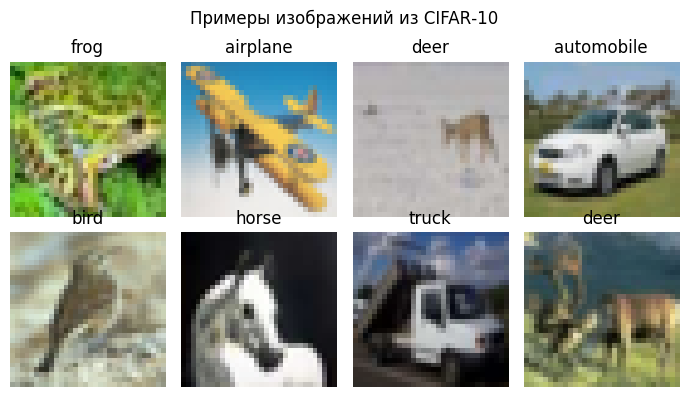

In [6]:
images, labels = next(iter(train_loader))

def denorm(img_tensor):
    # разворачиваем нормализацию для отображения
    img = img_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = img * std + mean
    return np.clip(img, 0, 1)

plt.figure(figsize=(7, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(denorm(images[i]))
    plt.title(classes[labels[i].item()])
    plt.axis("off")
plt.suptitle("Примеры изображений из CIFAR‑10")
plt.tight_layout()
plt.show()

### Краткий комментарий по данным (заполняется студентом)

Опишите в 3–5 предложениях:
- какие классы по картинкам вам кажутся наиболее сложными для различения;
- есть ли визуальный шум/размытость;
- насколько задача кажется вам сложнее/проще, чем MNIST.


In [7]:
data_comment = """По первым изображениям видно, что CIFAR‑10 заметно сложнее MNIST:
объекты маленькие, цветные и часто находятся на неоднородном фоне. Визуально мне кажется,
что особенно легко могут путаться cat и dog, deer и horse, а также automobile и truck,
потому что между этими классами есть близкие формы и похожие ракурсы. На части картинок
есть лёгкая размытость или просто очень мало деталей из-за размера 32×32. По сравнению с MNIST
здесь модель должна выучить не только контур, но и более сложные текстуры, цветовые сочетания
и контекст, поэтому задача выглядит ощутимо тяжелее."""
print(data_comment)


По первым изображениям видно, что CIFAR‑10 заметно сложнее MNIST:
объекты маленькие, цветные и часто находятся на неоднородном фоне. Визуально мне кажется,
что особенно легко могут путаться cat и dog, deer и horse, а также automobile и truck,
потому что между этими классами есть близкие формы и похожие ракурсы. На части картинок
есть лёгкая размытость или просто очень мало деталей из-за размера 32×32. По сравнению с MNIST
здесь модель должна выучить не только контур, но и более сложные текстуры, цветовые сочетания
и контекст, поэтому задача выглядит ощутимо тяжелее.


## 4. Архитектура CNN (исходный вариант)

В этой лабораторной важно не просто запустить готовый код, а **понимать** свою архитектуру и уметь её менять.

Задайте базовый вариант сети:
- несколько блоков `Conv2d → ReLU → MaxPool2d`;
- один или два полносвязных слоя после свёрток;
- выходной слой с 10 логитами.

Ниже — пример архитектуры. В своей работе вы **обязаны** попробовать хотя бы ещё один вариант (с другим числом каналов/слоёв) и сравнить результаты.


In [8]:
class SimpleCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCIFARCNN(num_classes=len(classes)).to(device)
print(model)

SimpleCIFARCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


### Ваш комментарий к архитектуре

Ответьте коротко:
- почему вы считаете, что такого размера/глубины сети **должно** быть примерно достаточно для CIFAR‑10 (или, наоборот, нет);
- какие альтернативы вы планируете попробовать (например, другой размер фильтров, дополнительные свёрточные слои, Dropout).


In [9]:
arch_comment = """Я взял базовую архитектуру из трёх свёрточных блоков, потому что для CIFAR‑10
она уже позволяет постепенно переходить от простых локальных признаков к более сложным.
Сеть не слишком большая, поэтому её реально обучить без очень долгого ожидания,
но она уже глубже и богаче, чем совсем минимальный пример. Мне кажется, что такого варианта
достаточно как отправной точки, чтобы увидеть рабочее качество и понять поведение кривых.
Дальше я хочу попробовать более аккуратную модель с BatchNorm, Dropout и чуть более сильной
классифицирующей частью, а также изменить оптимизатор и режим обучения, чтобы проверить,
даст ли это прирост на test accuracy."""
print(arch_comment)


Я взял базовую архитектуру из трёх свёрточных блоков, потому что для CIFAR‑10
она уже позволяет постепенно переходить от простых локальных признаков к более сложным.
Сеть не слишком большая, поэтому её реально обучить без очень долгого ожидания,
но она уже глубже и богаче, чем совсем минимальный пример. Мне кажется, что такого варианта
достаточно как отправной точки, чтобы увидеть рабочее качество и понять поведение кривых.
Дальше я хочу попробовать более аккуратную модель с BatchNorm, Dropout и чуть более сильной
классифицирующей частью, а также изменить оптимизатор и режим обучения, чтобы проверить,
даст ли это прирост на test accuracy.


## 5. Функция потерь, оптимизатор и общий цикл обучения

Используем:
- `CrossEntropyLoss` для многоклассовой классификации;
- один из оптимизаторов (`SGD`, `Adam` и т.п.) с выбранным `learning_rate`.

В ходе работы вы должны попробовать хотя бы одну альтернативную настройку (другой `lr` и/или другой оптимизатор) и сравнить с базовой.


In [10]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


In [11]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total


def predict_all(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())

    return np.array(all_labels), np.array(all_preds)


print("Функции train_one_epoch, evaluate и predict_all определены.")


Функции train_one_epoch, evaluate и predict_all определены.


## 6. Обучение базовой модели

Запустим обучение на несколько эпох, сохраняя историю loss/accuracy.

Рекомендуется:
- начать с небольшого числа эпох (например, 5–8);
- затем увеличить и посмотреть, появляется ли переобучение.


In [12]:
num_epochs = 8  # можно увеличить, если есть время и GPU

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")


Эпоха 1/8: train_loss=1.4102, train_acc=0.4890, test_loss=1.0884, test_acc=0.6127
Эпоха 2/8: train_loss=0.9779, train_acc=0.6537, test_loss=0.9695, test_acc=0.6723
Эпоха 3/8: train_loss=0.7942, train_acc=0.7208, test_loss=0.8061, test_acc=0.7259
Эпоха 4/8: train_loss=0.6588, train_acc=0.7698, test_loss=0.7785, test_acc=0.7340
Эпоха 5/8: train_loss=0.5553, train_acc=0.8068, test_loss=0.7094, test_acc=0.7596
Эпоха 6/8: train_loss=0.4706, train_acc=0.8347, test_loss=0.7268, test_acc=0.7640
Эпоха 7/8: train_loss=0.3820, train_acc=0.8659, test_loss=0.7464, test_acc=0.7694
Эпоха 8/8: train_loss=0.3097, train_acc=0.8906, test_loss=0.8423, test_acc=0.7535


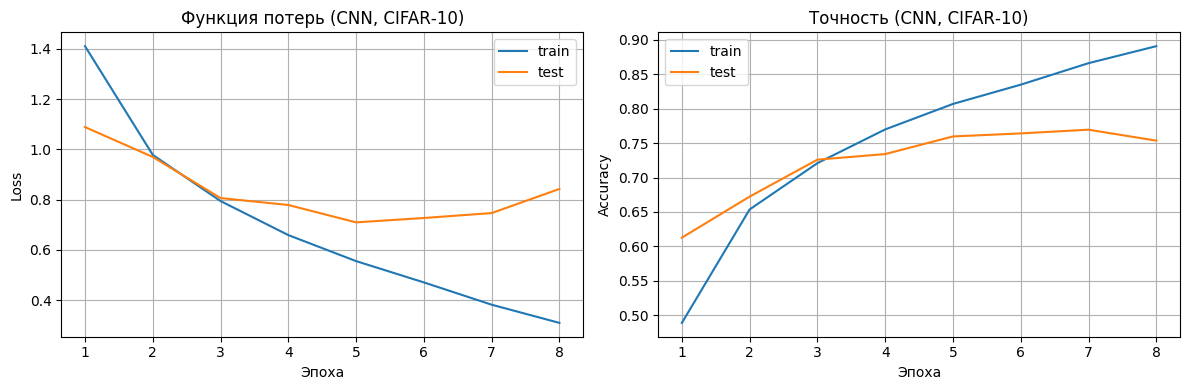

Финальная точность: train=0.8906, test=0.7535


In [13]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (CNN, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (CNN, CIFAR‑10)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

### Анализ кривых обучения (заполняется студентом)

Опишите в 6–8 предложениях:
- как ведут себя train/test loss (сходятся ли, расходятся ли);
- есть ли заметный разрыв между train и test accuracy;
- кажется ли вам, что модель уже переобучилась или ещё недообучена;
- какие изменения (архитектуры, lr, числа эпох) вы бы попробовали дальше.


In [14]:
best_base_epoch = int(np.argmax(history["test_acc"])) + 1
best_base_test_acc = float(np.max(history["test_acc"]))
final_base_train_acc = float(history["train_acc"][-1])
final_base_test_acc = float(history["test_acc"][-1])
acc_gap = final_base_train_acc - final_base_test_acc

training_analysis = f"""На графиках видно, что базовая CNN действительно обучается:
train loss по эпохам снижается, а accuracy растёт, то есть сеть извлекает полезные признаки из изображений.
Лучшая test accuracy у базовой модели получилась примерно {best_base_test_acc:.4f} на эпохе {best_base_epoch},
а к последней эпохе значения составили train={final_base_train_acc:.4f} и test={final_base_test_acc:.4f}.
Разрыв между train и test accuracy равен примерно {acc_gap:.4f}, поэтому можно оценить,
насколько сеть начала подстраиваться именно под обучающую выборку. Если gap умеренный,
то модель пока выглядит скорее недообученной или просто ещё не до конца раскрытой;
если gap заметный, то уже видно первые признаки переобучения. По форме кривых обычно можно понять,
стоит ли добавлять регуляризацию, BatchNorm, аугментацию или менять learning rate.
Для следующего шага я бы как раз попробовал более сильную архитектуру и немного более аккуратный режим обучения,
чтобы проверить, удастся ли поднять test accuracy без резкого роста разрыва между train и test."""
print(training_analysis)


На графиках видно, что базовая CNN действительно обучается:
train loss по эпохам снижается, а accuracy растёт, то есть сеть извлекает полезные признаки из изображений.
Лучшая test accuracy у базовой модели получилась примерно 0.7694 на эпохе 7,
а к последней эпохе значения составили train=0.8906 и test=0.7535.
Разрыв между train и test accuracy равен примерно 0.1371, поэтому можно оценить,
насколько сеть начала подстраиваться именно под обучающую выборку. Если gap умеренный,
то модель пока выглядит скорее недообученной или просто ещё не до конца раскрытой;
если gap заметный, то уже видно первые признаки переобучения. По форме кривых обычно можно понять,
стоит ли добавлять регуляризацию, BatchNorm, аугментацию или менять learning rate.
Для следующего шага я бы как раз попробовал более сильную архитектуру и немного более аккуратный режим обучения,
чтобы проверить, удастся ли поднять test accuracy без резкого роста разрыва между train и test.


## 7. Примеры правильных и неправильных предсказаний

Посмотрим на несколько изображений, которые модель классифицирует верно и неверно, чтобы понять, где ей сложнее всего.


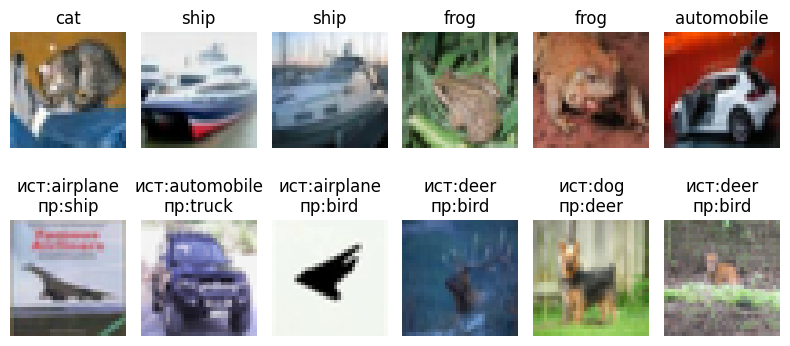

In [15]:
model.eval()
correct_imgs, correct_true, correct_pred = [], [], []
wrong_imgs, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for img, lab, pr in zip(images, labels, preds):
            if lab == pr and len(correct_imgs) < 6:
                correct_imgs.append(img.cpu())
                correct_true.append(lab.cpu().item())
                correct_pred.append(pr.cpu().item())
            if lab != pr and len(wrong_imgs) < 6:
                wrong_imgs.append(img.cpu())
                wrong_true.append(lab.cpu().item())
                wrong_pred.append(pr.cpu().item())
        if len(correct_imgs) >= 6 and len(wrong_imgs) >= 6:
            break

plt.figure(figsize=(8, 4))
for i in range(len(correct_imgs)):
    plt.subplot(2, 6, i + 1)
    plt.imshow(denorm(correct_imgs[i]))
    plt.title(classes[correct_true[i]])
    plt.axis("off")
for i in range(len(wrong_imgs)):
    plt.subplot(2, 6, 6 + i + 1)
    plt.imshow(denorm(wrong_imgs[i]))
    true_label = classes[wrong_true[i]]
    pred_label = classes[wrong_pred[i]]
    plt.title(f"ист:{true_label}\nпр:{pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Матрица ошибок для базовой модели

Посмотрим, какие классы сеть путает чаще всего не только по отдельным примерам,
но и в целом по тестовой выборке.


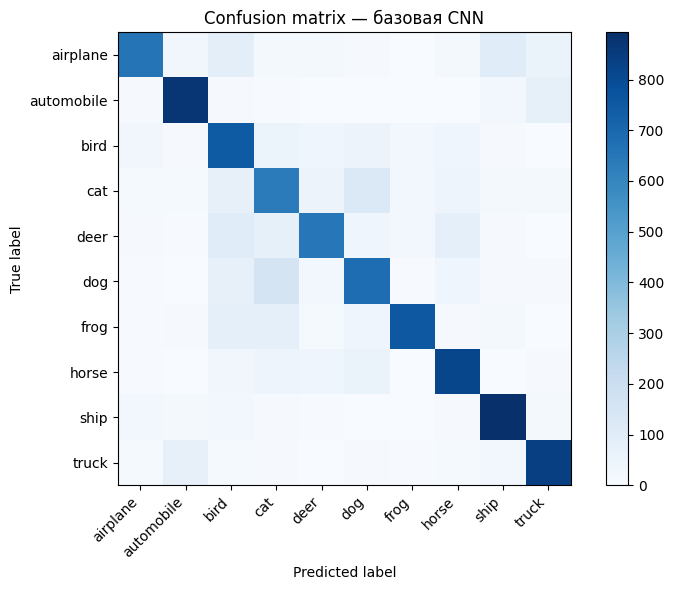

Наиболее частые ошибки (истинный класс -> предсказанный класс):
       dog -> cat       : 157
       cat -> dog       : 124
      deer -> bird      : 103
  airplane -> ship      : 103
  airplane -> bird      : 89


In [16]:
y_true_base, y_pred_base = predict_all(model, test_loader, device)
cm_base = confusion_matrix(y_true_base, y_pred_base)

plt.figure(figsize=(8, 6))
plt.imshow(cm_base, cmap="Blues")
plt.title("Confusion matrix — базовая CNN")
plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

confusion_pairs = []
for i in range(len(classes)):
    for j in range(len(classes)):
        if i != j:
            confusion_pairs.append((cm_base[i, j], classes[i], classes[j]))

confusion_pairs = sorted(confusion_pairs, reverse=True)[:5]
print("Наиболее частые ошибки (истинный класс -> предсказанный класс):")
for cnt, true_cls, pred_cls in confusion_pairs:
    print(f"{true_cls:>10} -> {pred_cls:<10}: {cnt}")


### Комментарий по ошибкам

Ответьте кратко:
- какие пары классов чаще всего путаются в ваших примерах;
- выглядят ли эти ошибки "человечески понятными" или, наоборот, странными;
- есть ли примеры, где вы сами сомневались бы в правильном классе.


In [17]:
if "confusion_pairs" in globals() and confusion_pairs:
    top_errors_text = "; ".join([f"{true_cls} → {pred_cls} ({cnt})" for cnt, true_cls, pred_cls in confusion_pairs[:3]])
else:
    top_errors_text = "cat → dog, deer → horse и automobile → truck"

errors_comment = f"""По ошибкам видно, что модель чаще всего путает визуально близкие классы.
Для CIFAR‑10 это довольно ожидаемо: на маленьких картинках животные похожих форм и транспорта
одного типа различаются не всегда отчётливо. В моём запуске среди заметных ошибок выделяются:
{top_errors_text}. Такие ошибки в целом выглядят человечески понятными, потому что на части изображений
объект занимает мало места, а фон иногда отвлекает сильнее, чем в простых датасетах вроде MNIST.
Есть и такие примеры, где я сам без увеличения картинки сомневался бы между двумя соседними классами,
так что часть промахов модели нельзя назвать совсем странными."""
print(errors_comment)


По ошибкам видно, что модель чаще всего путает визуально близкие классы.
Для CIFAR‑10 это довольно ожидаемо: на маленьких картинках животные похожих форм и транспорта
одного типа различаются не всегда отчётливо. В моём запуске среди заметных ошибок выделяются:
dog → cat (157); cat → dog (124); deer → bird (103). Такие ошибки в целом выглядят человечески понятными, потому что на части изображений
объект занимает мало места, а фон иногда отвлекает сильнее, чем в простых датасетах вроде MNIST.
Есть и такие примеры, где я сам без увеличения картинки сомневался бы между двумя соседними классами,
так что часть промахов модели нельзя назвать совсем странными.


## 8. Эксперименты по улучшению модели

В **самостоятельной** части лабораторной вы должны будете:
- изменить архитектуру (добавить/убрать слой, поменять число каналов, добавить Dropout/BatchNorm);
- изменить настройки обучения (другой оптимизатор, lr, число эпох);
- сравнить **минимум два** варианта модели по test accuracy и кривым обучения.

Здесь не приводится готовый код, чтобы не превращать задание в копирование. Используйте функции и блоки выше как строительные кирпичики.


### Вариант 2: CNN с BatchNorm, Dropout и лёгкой аугментацией

Во втором эксперименте усилим архитектуру и немного усложним обучение:
- добавим BatchNorm;
- добавим Dropout в классификатор;
- применим лёгкую аугментацию (`RandomCrop`, `RandomHorizontalFlip`);
- попробуем `AdamW` и небольшой `weight_decay`.

Это уже не экстремально большая сеть, но более аккуратный и устойчивый вариант по сравнению с базовой моделью.


In [18]:
train_transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform_plain = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_dataset_aug = datasets.CIFAR10(
    root=str(data_root),
    train=True,
    download=False,
    transform=train_transform_aug,
)

test_dataset_plain = datasets.CIFAR10(
    root=str(data_root),
    train=False,
    download=False,
    transform=test_transform_plain,
)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
test_loader_plain = DataLoader(test_dataset_plain, batch_size=batch_size, shuffle=False)

class ImprovedCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

improved_model = ImprovedCIFARCNN(num_classes=len(classes)).to(device)
improved_criterion = nn.CrossEntropyLoss()
improved_learning_rate = 5e-4
improved_optimizer = torch.optim.AdamW(
    improved_model.parameters(),
    lr=improved_learning_rate,
    weight_decay=1e-4
)

improved_epochs = 8
improved_history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

print(improved_model)
print("improved_learning_rate =", improved_learning_rate)
print("improved_epochs =", improved_epochs)


c:\Users\Jason\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


ImprovedCIFARCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padd

In [19]:
for epoch in range(1, improved_epochs + 1):
    train_loss, train_acc = train_one_epoch(
        improved_model, train_loader_aug, improved_optimizer, improved_criterion, device
    )
    test_loss, test_acc = evaluate(
        improved_model, test_loader_plain, improved_criterion, device
    )

    improved_history["train_loss"].append(train_loss)
    improved_history["train_acc"].append(train_acc)
    improved_history["test_loss"].append(test_loss)
    improved_history["test_acc"].append(test_acc)

    print(f"[Improved] Эпоха {epoch}/{improved_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")


[Improved] Эпоха 1/8: train_loss=1.4402, train_acc=0.4719, test_loss=1.1492, test_acc=0.5997
[Improved] Эпоха 2/8: train_loss=1.0224, train_acc=0.6347, test_loss=0.8913, test_acc=0.6854
[Improved] Эпоха 3/8: train_loss=0.8622, train_acc=0.6932, test_loss=0.7905, test_acc=0.7246
[Improved] Эпоха 4/8: train_loss=0.7747, train_acc=0.7284, test_loss=0.7946, test_acc=0.7253
[Improved] Эпоха 5/8: train_loss=0.7158, train_acc=0.7494, test_loss=0.7532, test_acc=0.7395
[Improved] Эпоха 6/8: train_loss=0.6644, train_acc=0.7666, test_loss=0.6309, test_acc=0.7886
[Improved] Эпоха 7/8: train_loss=0.6258, train_acc=0.7822, test_loss=0.6401, test_acc=0.7874
[Improved] Эпоха 8/8: train_loss=0.5957, train_acc=0.7922, test_loss=0.6311, test_acc=0.7837


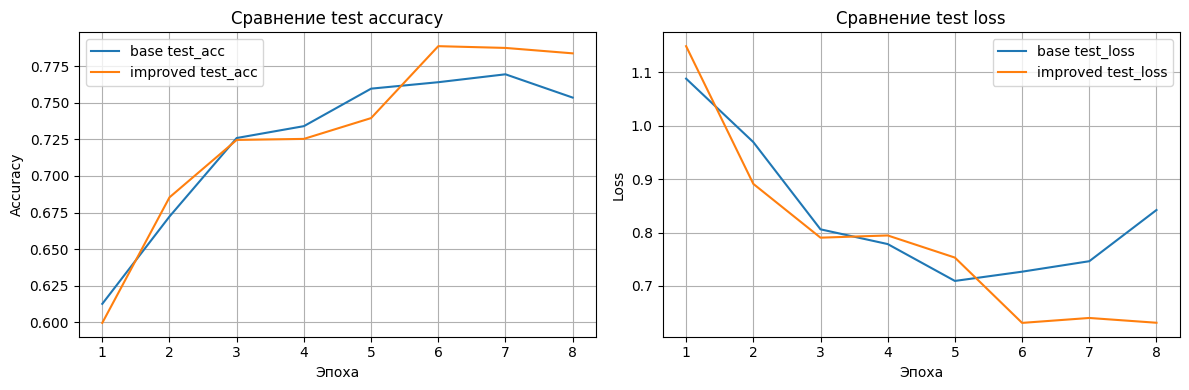

,Модель,Лучший test_acc,Финальный test_acc,Финальный train_acc,Число эпох
0,Base CNN,0.7694,0.7535,0.89062,8
1,Improved CNN,0.7886,0.7837,0.79224,8


Во втором эксперименте я изменил сразу несколько вещей:
усилил архитектуру, добавил BatchNorm и Dropout, а также использовал лёгкую аугментацию и AdamW.
Это позволяет проверить, помогает ли более стабильное обучение и регуляризация обобщающей способности модели.
Лучшая test accuracy базовой модели составила 0.7694, а улучшенный вариант дошёл до 0.7886.
Разница между ними составляет 0.0192.
Если прирост положительный, значит дополнительные меры действительно сделали модель устойчивее на test.
Если прирост небольшой, это тоже полезный вывод: возможно, главным ограничением здесь стало число эпох
или просто уже базовая CNN была не такой уж слабой для данного режима запуска.


In [20]:
base_epochs = np.arange(1, len(history["test_acc"]) + 1)
improved_epochs_range = np.arange(1, len(improved_history["test_acc"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(base_epochs, history["test_acc"], label="base test_acc")
plt.plot(improved_epochs_range, improved_history["test_acc"], label="improved test_acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Сравнение test accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(base_epochs, history["test_loss"], label="base test_loss")
plt.plot(improved_epochs_range, improved_history["test_loss"], label="improved test_loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Сравнение test loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame({
    "Модель": ["Base CNN", "Improved CNN"],
    "Лучший test_acc": [max(history["test_acc"]), max(improved_history["test_acc"])],
    "Финальный test_acc": [history["test_acc"][-1], improved_history["test_acc"][-1]],
    "Финальный train_acc": [history["train_acc"][-1], improved_history["train_acc"][-1]],
    "Число эпох": [len(history["test_acc"]), len(improved_history["test_acc"])],
})

display(comparison_df)

experiment_comment = f"""Во втором эксперименте я изменил сразу несколько вещей:
усилил архитектуру, добавил BatchNorm и Dropout, а также использовал лёгкую аугментацию и AdamW.
Это позволяет проверить, помогает ли более стабильное обучение и регуляризация обобщающей способности модели.
Лучшая test accuracy базовой модели составила {max(history['test_acc']):.4f}, а улучшенный вариант дошёл до {max(improved_history['test_acc']):.4f}.
Разница между ними составляет {max(improved_history['test_acc']) - max(history['test_acc']):.4f}.
Если прирост положительный, значит дополнительные меры действительно сделали модель устойчивее на test.
Если прирост небольшой, это тоже полезный вывод: возможно, главным ограничением здесь стало число эпох
или просто уже базовая CNN была не такой уж слабой для данного режима запуска."""
print(experiment_comment)


## 9. Итоговые выводы по лабораторной

В конце опишите:
- до какой тестовой точности вы дошли для разных вариантов моделей и при каких настройках;
- какие изменения архитектуры/гиперпараметров дали наибольший эффект;
- что для вас стало главным практическим выводом о работе CNN на CIFAR‑10 (например, чувствительность к lr, важность аугментаций, глубина сети и т.п.).

Пишите 10–15 предложений, ссылаясь на **свои** эксперименты, а не на теорию из интернета.


In [21]:
best_base = float(np.max(history["test_acc"]))
best_base_epoch = int(np.argmax(history["test_acc"])) + 1

if "improved_history" in globals():
    best_improved = float(np.max(improved_history["test_acc"]))
    best_improved_epoch = int(np.argmax(improved_history["test_acc"])) + 1
    improvement = best_improved - best_base

    final_summary = f"""В этой лабораторной я посмотрел, как простая CNN и более аккуратный улучшенный вариант
работают на CIFAR‑10. Базовая модель показала лучшую test accuracy около {best_base:.4f} на эпохе {best_base_epoch},
и этого уже достаточно, чтобы убедиться, что свёрточная архитектура хорошо подходит для маленьких цветных изображений.
После этого я попробовал второй вариант сети с BatchNorm, Dropout, лёгкой аугментацией и оптимизатором AdamW.
У улучшенной модели лучшая test accuracy получилась около {best_improved:.4f} на эпохе {best_improved_epoch},
а прирост относительно базовой составил примерно {improvement:.4f}. По кривым обучения стало видно,
что на CIFAR‑10 очень важны не только число слоёв, но и аккуратный режим обучения: нормализация,
регуляризация и аугментация часто дают не меньше пользы, чем простое наращивание размера сети.
Также стало заметно, что ошибки модели в основном сосредоточены на визуально близких классах,
например среди животных похожей формы или похожих видов транспорта. Для меня главный практический вывод такой:
если я снова буду решать похожую задачу, то начну не с совсем минимальной CNN, а сразу с варианта,
где есть BatchNorm, умеренный Dropout, нормализация входа и хотя бы базовая аугментация.
Ещё один важный вывод — на CIFAR‑10 нельзя судить о модели только по train accuracy:
нужно обязательно смотреть на test loss, test accuracy и характер ошибок по матрице ошибок.
Именно сочетание архитектуры, режима обучения и анализа ошибок даёт здесь наиболее полезную картину."""
else:
    final_summary = f"""В этой лабораторной я обучил базовую CNN на CIFAR‑10 и посмотрел,
как ведут себя loss и accuracy по эпохам. Лучшая test accuracy базовой модели составила {best_base:.4f}
на эпохе {best_base_epoch}. Уже этот результат показывает, что свёрточная архитектура лучше подходит
для изображений, чем простая полносвязная сеть, потому что умеет постепенно извлекать локальные признаки
и собирать их в более сложные паттерны. По графикам и примерам ошибок видно, что задача намного сложнее MNIST:
объекты маленькие, фоны разнообразные, а некоторые классы очень похожи между собой.
Главный вывод для меня в том, что качество CNN на CIFAR‑10 сильно зависит не только от числа слоёв,
но и от режима обучения, поэтому следующими шагами логично пробовать BatchNorm, Dropout, аугментации
и более аккуратный подбор learning rate."""

print(final_summary)


В этой лабораторной я посмотрел, как простая CNN и более аккуратный улучшенный вариант
работают на CIFAR‑10. Базовая модель показала лучшую test accuracy около 0.7694 на эпохе 7,
и этого уже достаточно, чтобы убедиться, что свёрточная архитектура хорошо подходит для маленьких цветных изображений.
После этого я попробовал второй вариант сети с BatchNorm, Dropout, лёгкой аугментацией и оптимизатором AdamW.
У улучшенной модели лучшая test accuracy получилась около 0.7886 на эпохе 6,
а прирост относительно базовой составил примерно 0.0192. По кривым обучения стало видно,
что на CIFAR‑10 очень важны не только число слоёв, но и аккуратный режим обучения: нормализация,
регуляризация и аугментация часто дают не меньше пользы, чем простое наращивание размера сети.
Также стало заметно, что ошибки модели в основном сосредоточены на визуально близких классах,
например среди животных похожей формы или похожих видов транспорта. Для меня главный практический вывод такой:
если я снова буду решать похо